# PS: P-Spline with Gaussian IWLS proposals

## Setup and Imports

In [20]:
import jax.numpy as jnp
import liesel.goose as gs
import liesel.model as lsl
import numpy as np
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel_gam as gam
from liesel_gam.iwls_proposals import (
    GaussianLocIWLSProposal,
    GaussianScaleIWLSProposal,
    apply_gaussian_iwls_spec_loc,
    apply_gaussian_iwls_spec_scale,
)


In [21]:
from scipy import stats

rng = np.random.default_rng(1)
x = rng.uniform(-2, 2, 200)

log_sigma = -1.0 + 0.3 * (
    0.5 * x + 15 * stats.norm.pdf(2 * (x - 0.2)) - stats.norm.pdf(x + 0.4)
)
mu = -x + np.pi * np.sin(np.pi * x)
y = mu + jnp.exp(log_sigma) * rng.normal(0.0, 1.0, 200)

df = pd.DataFrame({"y": y, "x": x})

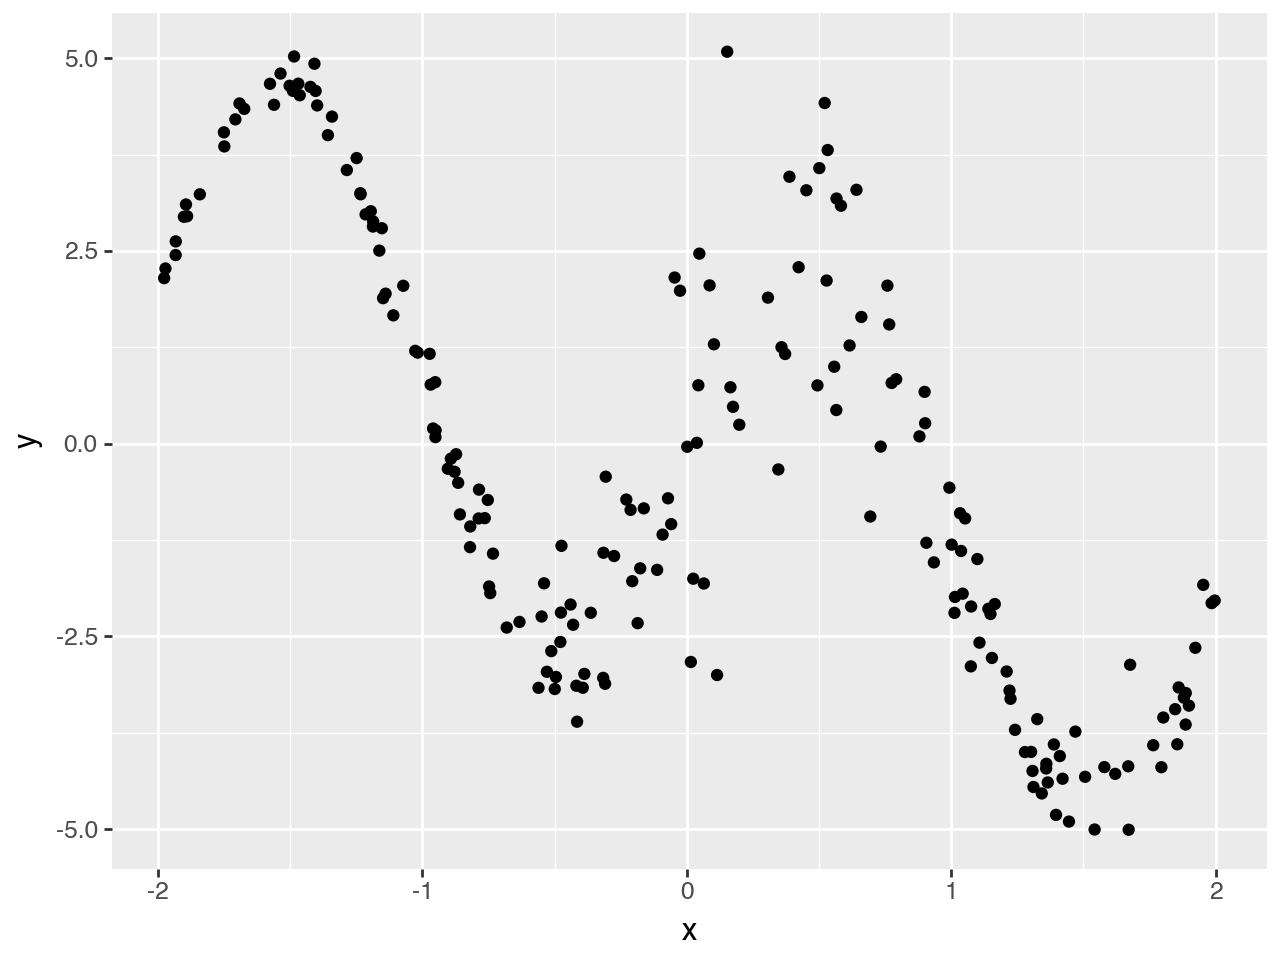

In [22]:
(p9.ggplot(df) + p9.geom_point(p9.aes("x", "y")))

## Model Definition

### Setup response model

In [23]:
loc = gam.AdditivePredictor("loc")
scale = gam.AdditivePredictor("scale", inv_link=jnp.exp)


y = lsl.Var.new_obs(
    value=df.y.to_numpy(),
    distribution=lsl.Dist(tfd.Normal, loc=loc, scale=scale),
    name="y",
)


registry = gam.PandasRegistry(df)
tbl = gam.TermBuilder(registry, prefix_names_by="loc.")
tbs = gam.TermBuilder(registry, prefix_names_by="scale.")

loc_ps = tbl.ps("x", k=20)
scale_ps = tbs.ps("x", k=20)

loc += loc_ps
scale += scale_ps


### Build model and configure IWLS proposals

This version configures Gaussian IWLS proposals explicitly via
`GaussianLocIWLSProposal` and `GaussianScaleIWLSProposal`. For production code, the
bulk helpers `apply_gaussian_iwls_spec_loc()` and
`apply_gaussian_iwls_spec_scale()` provide the same assignment pattern for all
supported structured terms in a predictor.


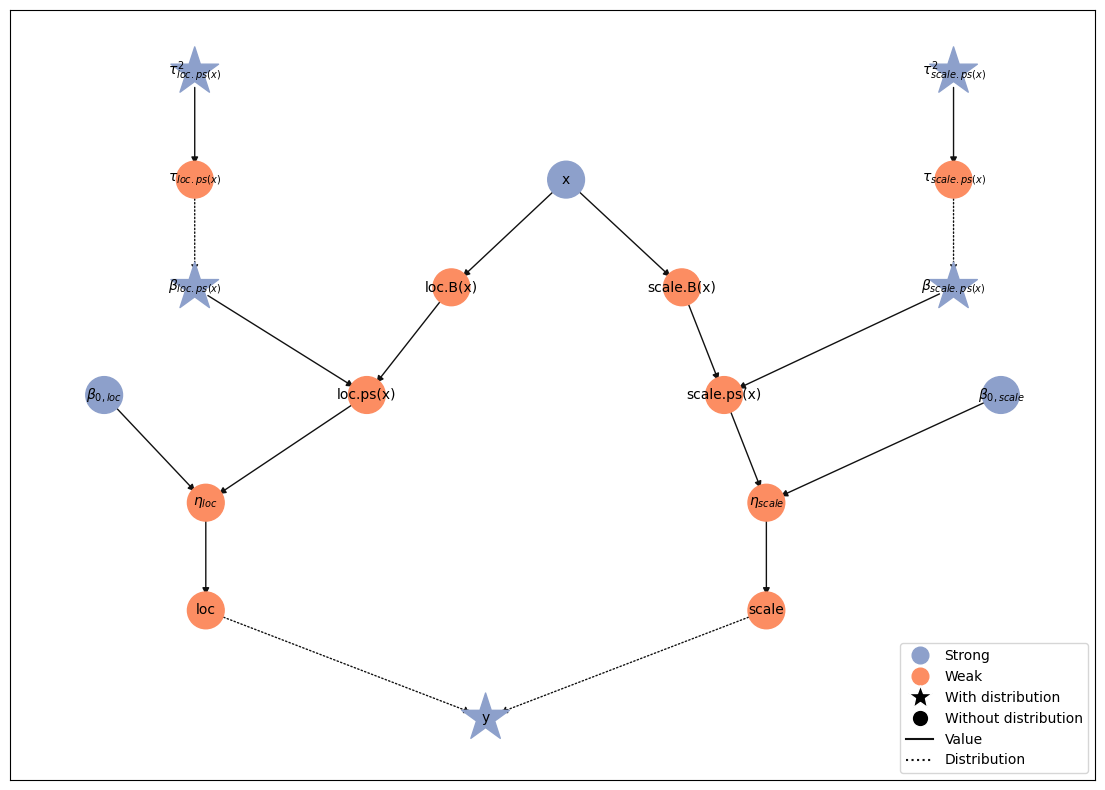

In [24]:
model = lsl.Model([y])

# Bulk alternative:
# apply_gaussian_iwls_spec_loc(loc, scale_name=scale.name, fallback_chol_info=None)
# apply_gaussian_iwls_spec_scale(scale, fallback_chol_info=None)
loc_iwls = GaussianLocIWLSProposal.from_term(loc_ps, scale_name=scale.name)
scale_iwls = GaussianScaleIWLSProposal.from_term(scale_ps)

loc_ps.coef.inference = gs.MCMCSpec(
    kernel=loc_iwls.kernel_factory(),
    kernel_kwargs={"fallback_chol_info": None},
)
scale_ps.coef.inference = gs.MCMCSpec(
    kernel=scale_iwls.kernel_factory(),
    kernel_kwargs={"fallback_chol_info": None},
)

model.plot_vars()


## Run MCMC

In [25]:
eb = gs.LieselMCMC(model).get_engine_builder(seed=1, num_chains=4)

eb.add_adaptation(3000)
eb.add_posterior(10_000, thinning=10)

engine = eb.build()
engine.sample_all_epochs()
results = engine.get_results()

liesel.goose.builder - WARNING - No jitter functions provided for position keys '$\\beta_{loc.ps(x)}$', '$\\beta_{scale.ps(x)}$', '$\\tau_{loc.ps(x)}^2$', '$\\beta_{0,loc}$', '$\\tau_{scale.ps(x)}^2$', '$\\beta_{0,scale}$'. The initial values for these keys won't be jittered


liesel.goose.engine - INFO - Initializing kernels...
liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 300 transitions, 25 jitted together
100%|████████████████████████████████████████| 12/12 [00:02<00:00,  4.08chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|████████████████████████████████████████| 1/1 [00:00<00:00, 1159.93chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 50 transitions, 25 jitted together
100%|████████████████████████████████████████| 2/2 [00:00<00:00, 1563.87chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 100 transitions, 25 jitted together
100%|████████████████████████████████████████| 4/4 [00:00<00:00, 1410.44chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - I

### MCMC summary

In [26]:
summary = gs.Summary(results)
summary

Parameter summary:

                                 kernel      mean        sd    q_0.05  \
parameter              index                                            
$\beta_{0,loc}$        ()     kernel_03 -0.322821  0.058497 -0.421899   
$\beta_{0,scale}$      ()     kernel_05 -0.626906  0.053348 -0.713052   
$\beta_{loc.ps(x)}$    (0,)   kernel_00  0.154201  0.337093 -0.390599   
                       (1,)   kernel_00 -0.138626  0.294180 -0.637200   
                       (2,)   kernel_00  0.137071  0.298995 -0.342696   
                       (3,)   kernel_00  0.139893  0.291617 -0.329262   
                       (4,)   kernel_00 -0.259759  0.285662 -0.737290   
                       (5,)   kernel_00  0.024039  0.263003 -0.416194   
                       (6,)   kernel_00  0.006447  0.250554 -0.397454   
                       (7,)   kernel_00  0.115668  0.226086 -0.247734   
                       (8,)   kernel_00  0.062981  0.220429 -0.291808   
                       (9,)   kernel_00  0.078988  0.180414 -0.210667   
                       (10,)  kernel_00  0.084873  0.168710 -0.201906   
                       (11,)  kernel_00 -0.048375  0.136700 -0.274053   
                       (12,)  kernel_00  0.074017  0.114764 -0.114649   
                       (13,)  kernel_00 -0.079499  0.086948 -0.223269   
                       (14,)  kernel_00  1.231708  0.064207  1.125414   
                       (15,)  kernel_00  0.024312  0.041415 -0.044851   
                       (16,)  kernel_00 -0.015380  0.021821 -0.051518   
                       (17,)  kernel_00  0.010025  0.008933 -0.004899   
                       (18,)  kernel_00 -0.423345  0.031202 -0.473632   
$\beta_{scale.ps(x)}$  (0,)   kernel_01  0.010912  0.076803 -0.109586   
                       (1,)   kernel_01 -0.011204  0.078401 -0.139438   
                       (2,)   kernel_01 -0.008662  0.078400 -0.132667   
                       (3,)   kernel_01 -0.004505  0.075192 -0.128374   
                       (4,)   kernel_01  0.004700  0.078152 -0.119569   
                       (5,)   kernel_01 -0.005912  0.076354 -0.128621   
                       (6,)   kernel_01  0.026339  0.076988 -0.089847   
                       (7,)   kernel_01  0.032104  0.072377 -0.080243   
                       (8,)   kernel_01  0.012112  0.072905 -0.105969   
                       (9,)   kernel_01 -0.014069  0.069026 -0.129472   
                       (10,)  kernel_01  0.014455  0.069439 -0.095272   
                       (11,)  kernel_01  0.007466  0.064494 -0.097293   
                       (12,)  kernel_01  0.068426  0.060251 -0.026005   
                       (13,)  kernel_01 -0.066222  0.051579 -0.151276   
                       (14,)  kernel_01  0.058335  0.041382 -0.008117   
                       (15,)  kernel_01  0.079374  0.029277  0.030649   
                       (16,)  kernel_01  0.005497  0.016842 -0.021659   
                       (17,)  kernel_01 -0.041847  0.007104 -0.053394   
                       (18,)  kernel_01  0.128033  0.027662  0.081471   
$\tau_{loc.ps(x)}^2$   ()     kernel_02  0.139930  0.061553  0.069229   
$\tau_{scale.ps(x)}^2$ ()     kernel_04  0.005972  0.004373  0.001957   

                                 q_0.5    q_0.95  sample_size     ess_bulk  \
parameter              index                                                 
$\beta_{0,loc}$        ()    -0.320828 -0.229215         4000   602.806654   
$\beta_{0,scale}$      ()    -0.627121 -0.539213         4000  3776.953164   
$\beta_{loc.ps(x)}$    (0,)   0.155188  0.708238         4000  3682.530183   
                       (1,)  -0.136174  0.332096         4000  3649.547470   
                       (2,)   0.131760  0.636301         4000  3628.233565   
                       (3,)   0.135104  0.627115         4000  3279.743126   
                       (4,)  -0.254285  0.202569         4000  3376.313890   
                       (5,)   0.022862  0.453284         4000  31

### MCMC trace plots

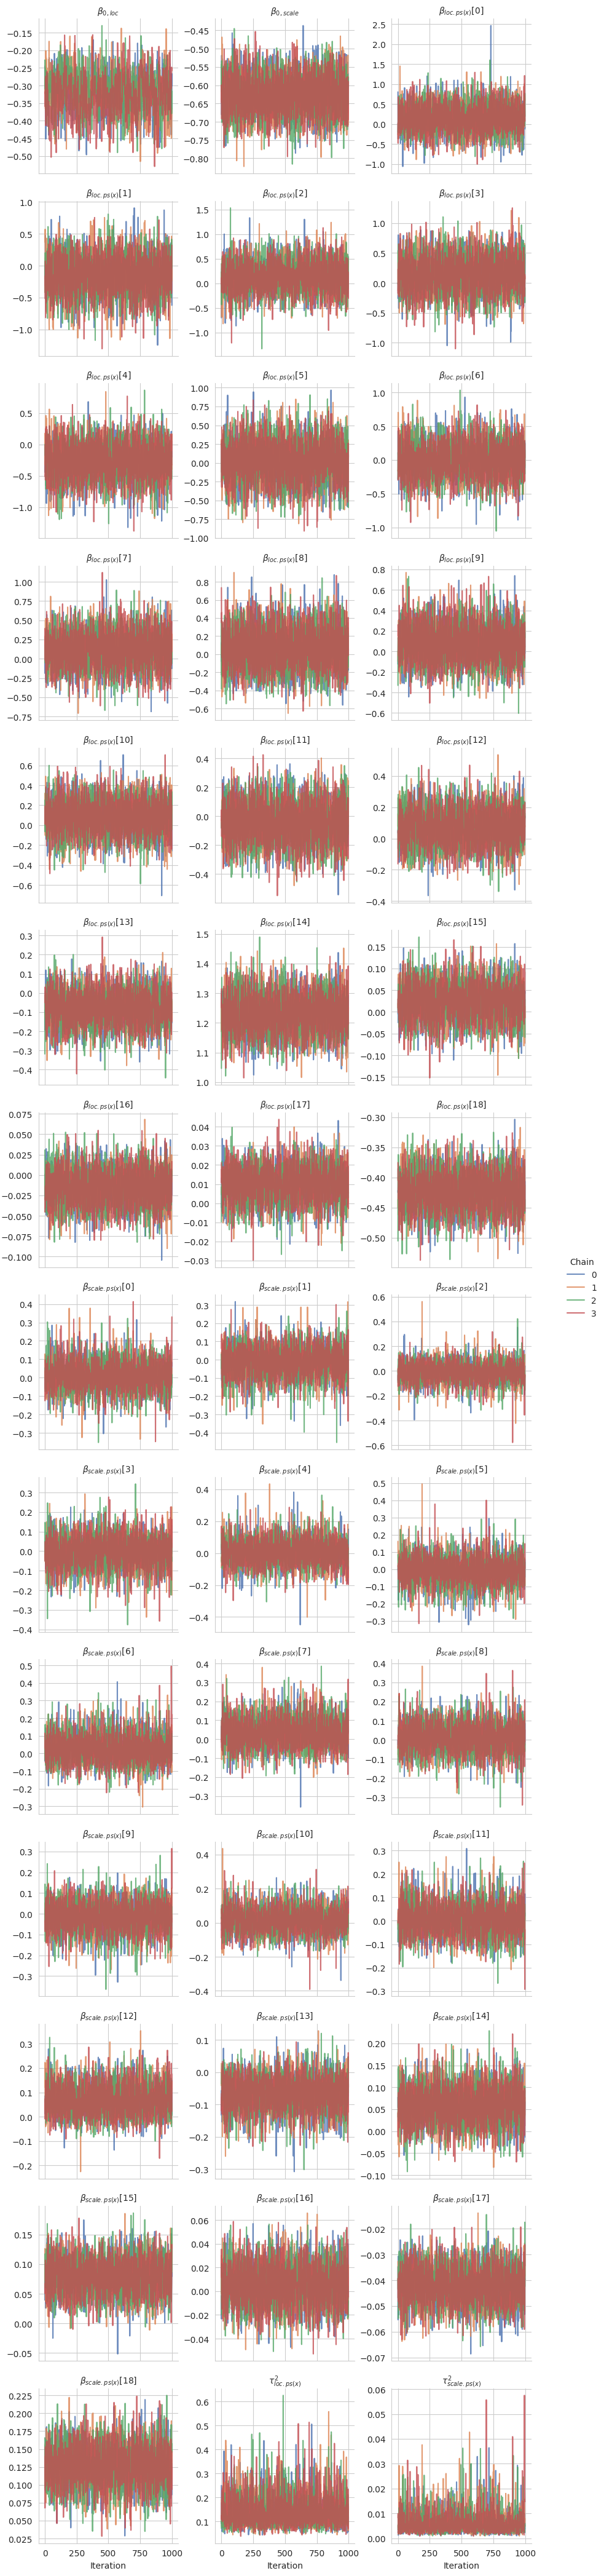

In [27]:
gs.plot_trace(results)

## Predictions

In [28]:
samples = results.get_posterior_samples()

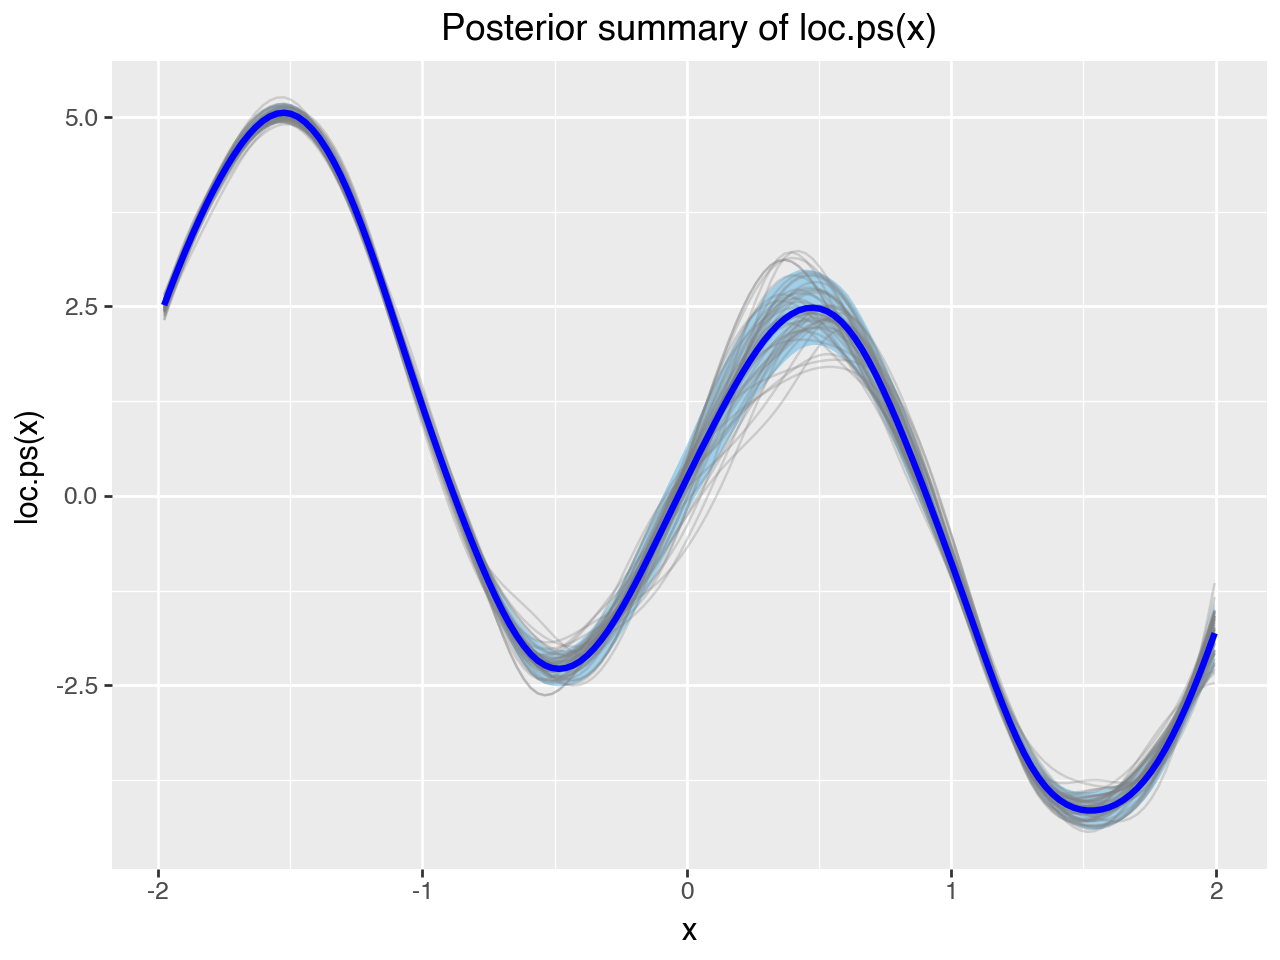

In [29]:
gam.plot_1d_smooth(term=model.vars["loc.ps(x)"], samples=samples)

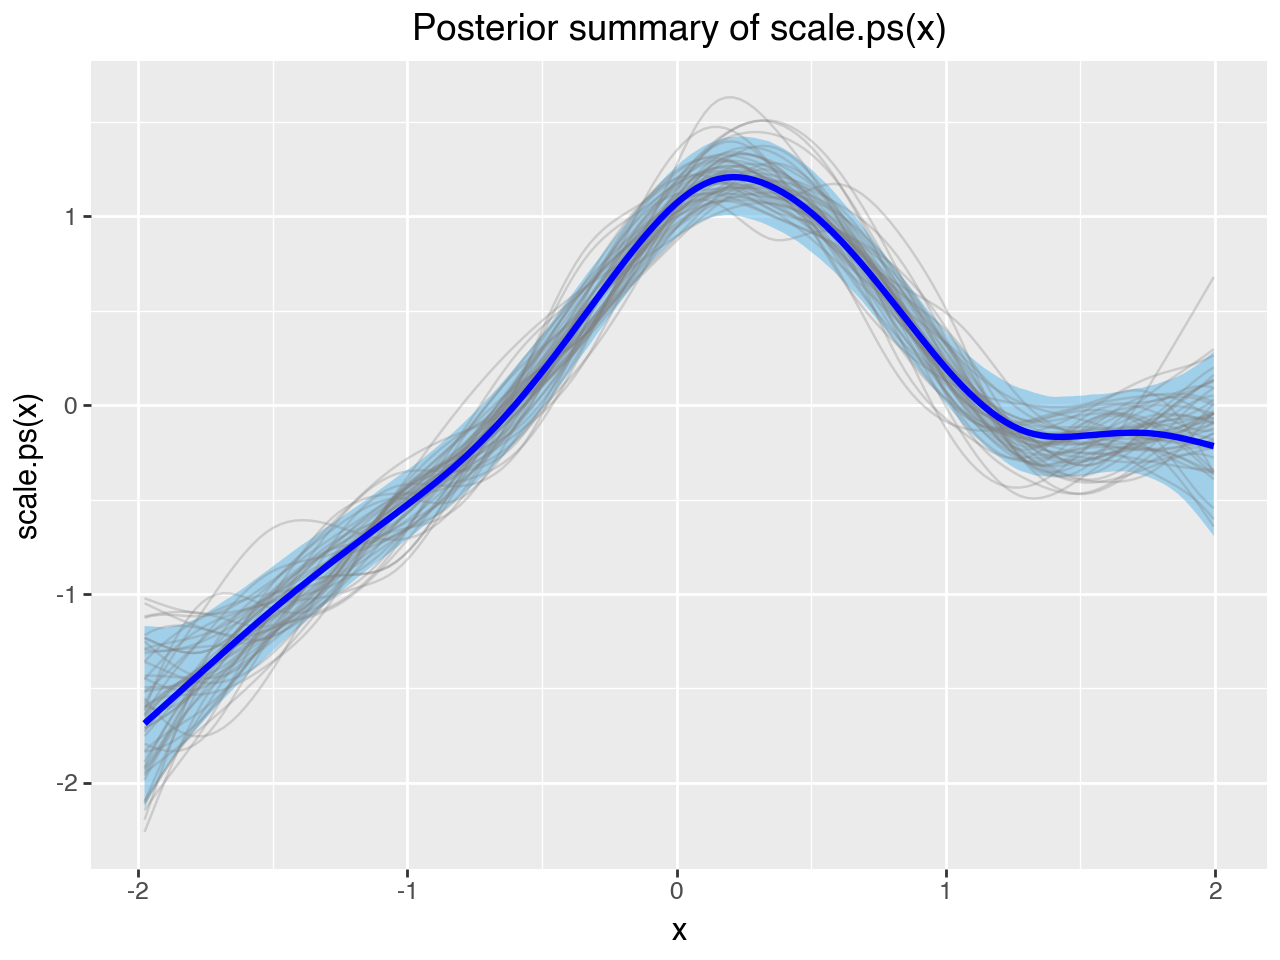

In [30]:
gam.plot_1d_smooth(term=model.vars["scale.ps(x)"], samples=samples)

### Predict variables at new x values

In [31]:
x_grid = jnp.linspace(df.x.min(), df.x.max(), 300)

predictions = model.predict(
    samples=samples,
    predict=["loc.ps(x)", "scale.ps(x)", "loc", "scale"],
    newdata={"x": x_grid},
)

predictions_summary = gs.SamplesSummary(predictions).to_dataframe().reset_index()
predictions_summary["x"] = np.tile(x_grid, len(predictions))

### Plot parameters as functions of covariate

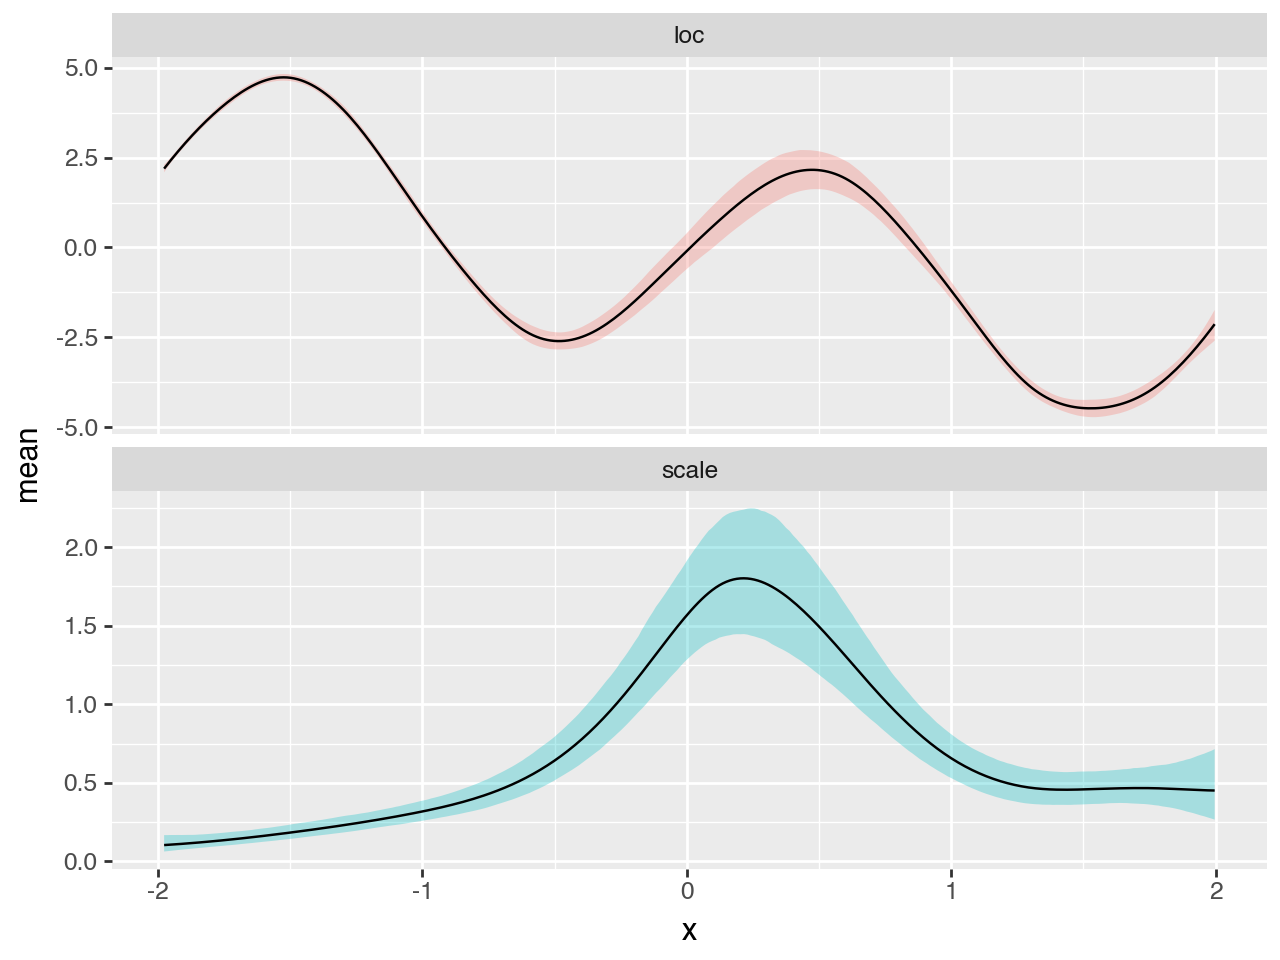

In [32]:
select = predictions_summary["variable"].isin(["loc", "scale"])
(
    p9.ggplot(predictions_summary[select])
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95", fill="variable"), alpha=0.3
    )
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.facet_wrap("~variable", scales="free_y", ncol=1)
    + p9.guides(fill="none")
)

### Plot fitted location with raw data

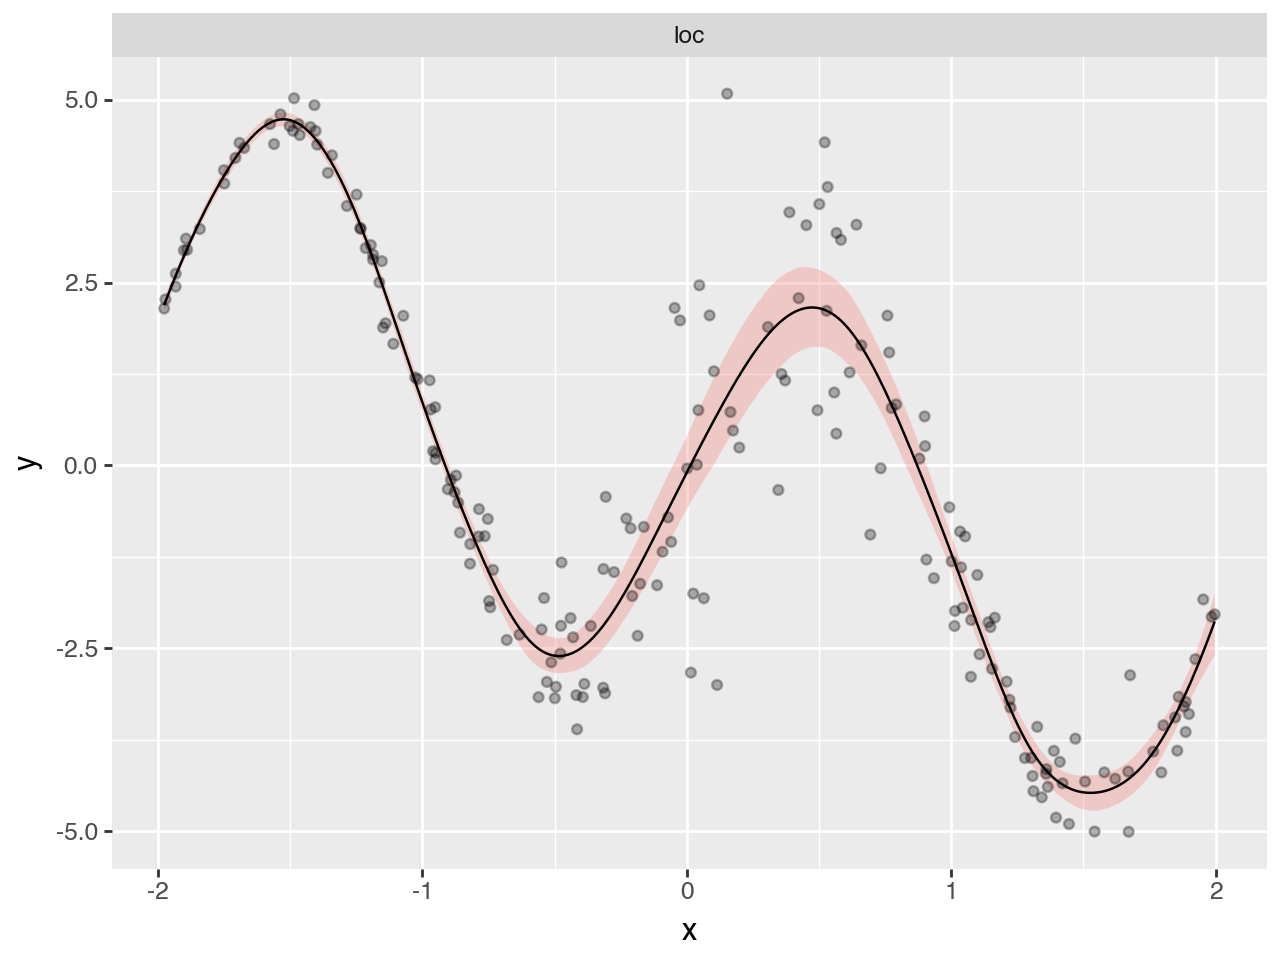

In [33]:
select = predictions_summary["variable"].isin(["loc"])
(
    p9.ggplot(predictions_summary[select])
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95", fill="variable"), alpha=0.3
    )
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.facet_wrap("~variable", scales="free_y", ncol=1)
    + p9.guides(fill="none")
)

### Posterior predictive distribution

In [34]:
select = predictions_summary["variable"].isin(["loc", "scale"])
mu_sigma_df = (
    predictions_summary[select][["variable", "mean", "x"]]
    .pivot(index="x", columns=["variable"], values="mean")
    .reset_index()
)

mu_sigma_df["low"] = mu_sigma_df["loc"] - mu_sigma_df["scale"]
mu_sigma_df["high"] = mu_sigma_df["loc"] + mu_sigma_df["scale"]
mu_sigma_df

variable,x,loc,scale,low,high
0,-1.976702,2.194222,0.103696,2.090526,2.297918
1,-1.963415,2.318694,0.105121,2.213573,2.423815
2,-1.950128,2.440712,0.106598,2.334114,2.547310
3,-1.936841,2.560259,0.108127,2.452132,2.668386
4,-1.923554,2.677304,0.109706,2.567598,2.787010
...,...,...,...,...,...
295,1.942956,-2.638083,0.453509,-3.091592,-2.184574
296,1.956243,-2.516587,0.452719,-2.969306,-2.063868
297,1.969530,-2.392057,0.452027,-2.844085,-1.940030
298,1.982817,-2.264613,0.451449,-2.716062,-1.813164


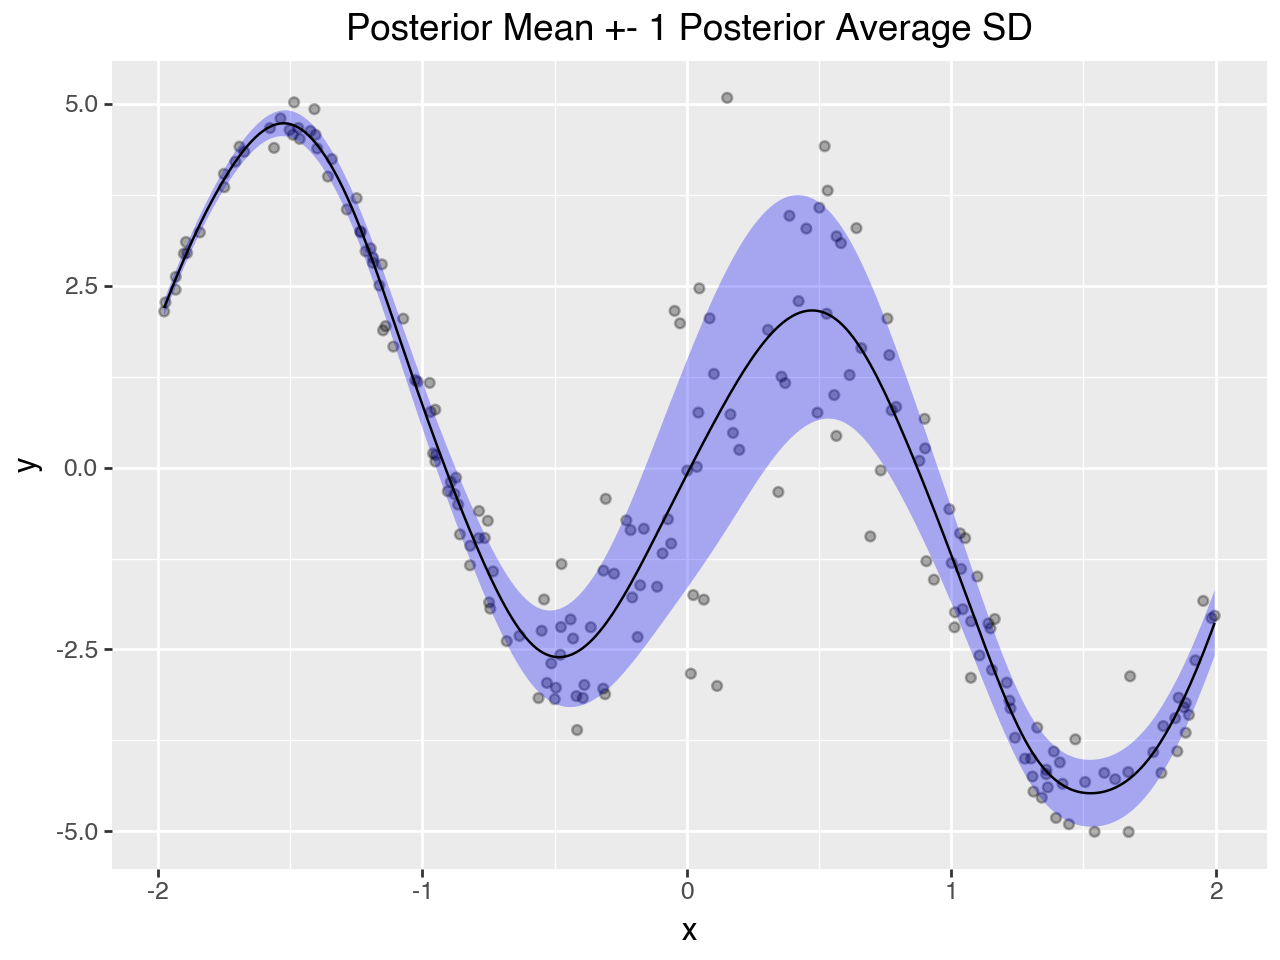

In [35]:
(
    p9.ggplot()
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_ribbon(
        p9.aes("x", ymin="low", ymax="high"),
        alpha=0.3,
        fill="blue",
        data=mu_sigma_df,
    )
    + p9.geom_line(p9.aes("x", "loc"), data=mu_sigma_df)
    + p9.labs(title="Posterior Mean +- 1 Posterior Average SD")
    + p9.guides(fill="none")
)

### Sample from posterior predictive distribution

In [36]:
import jax

ppsamples = model.sample(shape=(), seed=jax.random.key(1), posterior_samples=samples)

ppsamples["y"].shape

(4, 1000, 200)

In [37]:
# summarise ppsamples
ppsamples_summary = gs.SamplesSummary(ppsamples).to_dataframe().reset_index()

# add covariate to df
ppsamples_summary["x"] = df["x"].to_numpy()

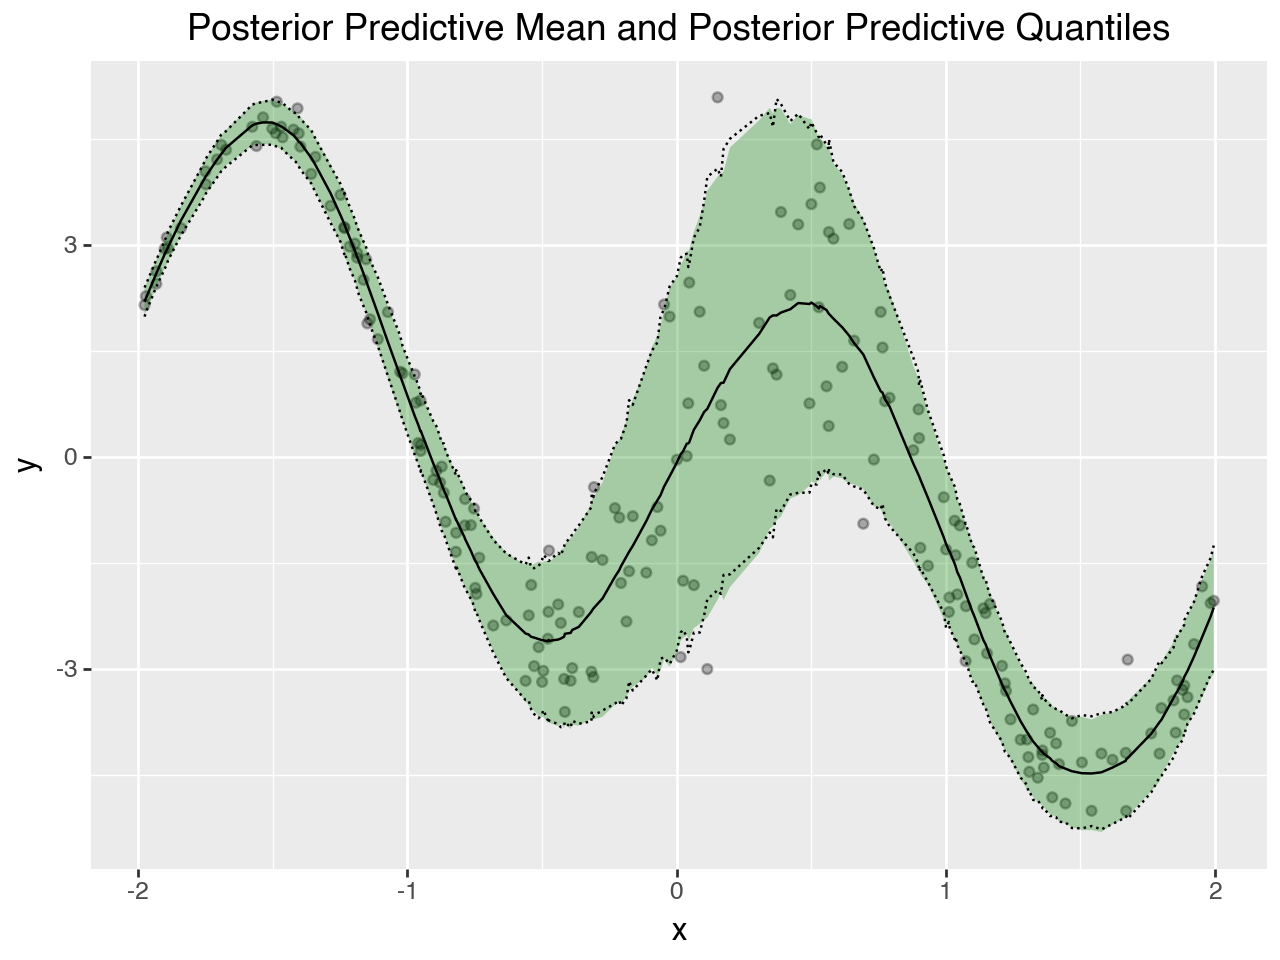

In [38]:
(
    p9.ggplot(ppsamples_summary)
    + p9.geom_point(p9.aes("x", "y"), data=df, alpha=0.3)
    + p9.geom_ribbon(
        p9.aes("x", ymin="q_0.05", ymax="q_0.95"),
        alpha=0.3,
        fill="green",
    )
    + p9.geom_line(p9.aes("x", "hdi_low"), linetype="dotted")
    + p9.geom_line(p9.aes("x", "hdi_high"), linetype="dotted")
    + p9.geom_line(p9.aes("x", "mean"))
    + p9.labs(title="Posterior Predictive Mean and Posterior Predictive Quantiles")
    + p9.guides(fill="none")
)